In [9]:
import pandas as pd
df=pd.read_csv("heartdisease1.csv")
print(df.head())
print(df["target"].value_counts())

   age  sex  cp  trestbps  chol  fbs  thalach  exang  oldpeak  ca  target
0   49    0   3       177   150    0       95      0      2.3   0       0
1   56    1   0       124   172    1       86      1      0.5   0       1
2   66    0   3       100   239    0      105      0      1.7   0       0
3   64    0   0       168   222    0       95      1      2.8   0       1
4   60    1   2       153   358    0      147      0      3.2   0       1
1    11
0     5
Name: target, dtype: int64


In [10]:
x=df.drop("target",axis=1)
y=df["target"]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [30]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)
pred=dt.predict(x_test)
print(pred[ :10])

[1 1 1 1]


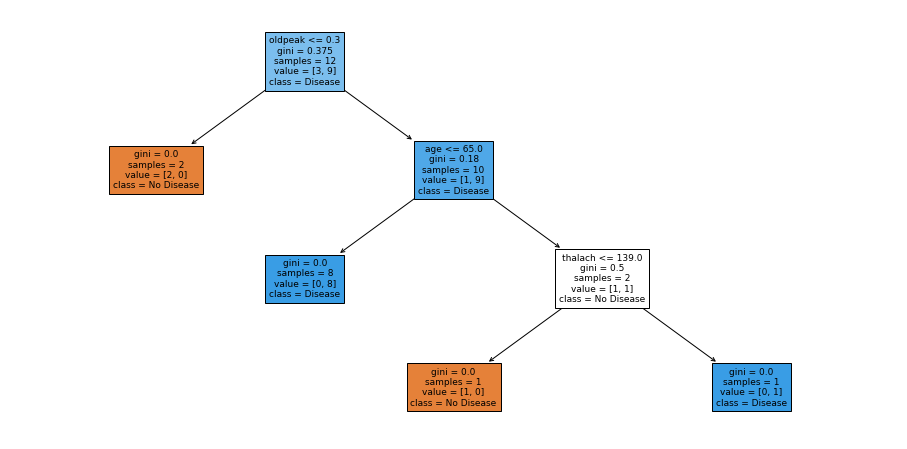

In [23]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(16,8))
plot_tree(dt,feature_names=x.columns,
         class_names=["No Disease","Disease"],filled=True,max_depth=3,fontsize=9)
plt.show()

In [13]:
for depth in[2,3,4,5,None]:
    dt_d=DecisionTreeClassifier(
    max_depth=depth,random_state=42
    )
    dt_d.fit(x_train,y_train)
    train_acc=dt_d.score(x_train,y_train)
    test_acc=dt_d.score(x_test,y_test)
    print(depth,train_acc,test_acc)

2 0.9166666666666666 0.5
3 1.0 0.5
4 1.0 0.5
5 1.0 0.5
None 1.0 0.5


In [14]:
for depth in[2,3,4,5,None]:
    dt_d=DecisionTreeClassifier(
    max_depth=depth,random_state=42
    )
    dt_d.fit(x_train,y_train)
    train_acc=dt_d.score(x_train,y_train)
    test_acc=dt_d.score(x_test,y_test)
    print("max_depth=",depth,"-> Train_acc:",round(test_acc,3),"Test acc:",round(test_acc,3))

max_depth= 2 -> Train_acc: 0.5 Test acc: 0.5
max_depth= 3 -> Train_acc: 0.5 Test acc: 0.5
max_depth= 4 -> Train_acc: 0.5 Test acc: 0.5
max_depth= 5 -> Train_acc: 0.5 Test acc: 0.5
max_depth= None -> Train_acc: 0.5 Test acc: 0.5


In [16]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(
n_estimators=100,random_state=42
)
rf.fit(x_train,y_train)
prep_rf=rf.predict(x_test)

thalach     0.264213
oldpeak     0.246059
age         0.140648
trestbps    0.098392
cp          0.063815
chol        0.054584
exang       0.047832
ca          0.047406
sex         0.037053
fbs         0.000000
dtype: float64


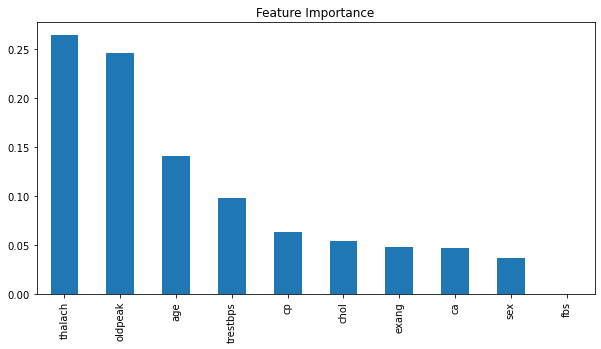

In [20]:
importances=rf.feature_importances_
feat_imp=pd.Series(
importances,index=x.columns
).sort_values(ascending=False)
print(feat_imp)
feat_imp.plot(kind="bar",figsize=(10,5))
plt.title("Feature Importance")
plt.show()

In [22]:
for n in [50,100,200]:
    for depth in [3,5,None]:
        rf_t=RandomForestClassifier(
        n_estimators=n,max_depth=depth,
        random_state=42
        )
    rf_t.fit(x_train,y_train)
    acc=rf_t.score(x_test,y_test)
    print("n_estimators=",n,"-> max_depth=",depth," ->Accuracy:",round(acc,3))

n_estimators= 50 -> max_depth= None  ->Accuracy: 0.25
n_estimators= 100 -> max_depth= None  ->Accuracy: 0.5
n_estimators= 200 -> max_depth= None  ->Accuracy: 0.5


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
models={
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "KNN(K=5)":KNeighborsClassifier(n_neighbors=5),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "RandomForest":RandomForestClassifier(n_estimators=100,random_state=42),
}
results=[]
for name,m in models.items():
    m.fit(x_train,y_train)
    p=m.predict(x_test)
    results.append([
        name,
        accuracy_score(y_test,p),
        precision_score(y_test,p),
        recall_score (y_test,p),
        f1_score(y_test,p),
    ])
comparision_df=pd.DataFrame(results,columns=["Model","Accuracy","precision","Recall","F1 Score"])
print(comparision_df)

                 Model  Accuracy  precision  Recall  F1 Score
0  Logistic Regression      0.25   0.333333     0.5  0.400000
1             KNN(K=5)      0.50   0.500000     1.0  0.666667
2        Decision Tree      0.50   0.500000     1.0  0.666667
3         RandomForest      0.50   0.500000     1.0  0.666667
